<a href="https://colab.research.google.com/github/vadapallimaneesha/machine_learning-/blob/main/Week5portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   **Installation of PySpark**: This cell installs the `pyspark` library. PySpark is the Python API for Apache Spark, a powerful open-source, distributed processing system designed for big data analytics.

In [ ]:
!pip install pyspark

*   **Mounting Google Drive**: This cell imports the `drive` module from `google.colab`.
*   It then mounts your Google Drive to the Colab environment.
*   This step is essential for the notebook to access files stored in your Google Drive, such as the `customer_segmentation_dataset.csv` file that will be used later.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*   **Importing PySpark Modules**: This cell imports necessary classes from PySpark's `sql` and `ml` modules for data processing and machine learning:
    *   `SparkSession`: Used to create an entry point to programming Spark with the Dataset and DataFrame API.
    *   `VectorAssembler`, `StringIndexer`: These are feature transformers used for preparing data for machine learning models.
    *   `DecisionTreeClassifier`, `LogisticRegression`: These are specific machine learning classification algorithms.
    *   `MulticlassClassificationEvaluator`: Used for evaluating the performance of classification models.
*   **Initializing Spark Session**: A SparkSession named "Logistic Regression" is initialized. This is the starting point for interacting with Spark functionalities.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Spark session
spark = SparkSession.builder \
    .appName("Logistic Regression") \
    .getOrCreate()

*   **Loading Data from CSV**: This cell reads the `customer_segmentation_dataset.csv` file.
*   The file is located in your Google Drive at `/content/drive/MyDrive/customer_segmentation_dataset.csv`.
*   `inferSchema=True`: Instructs Spark to automatically determine the data types of columns.
*   `header=True`: Indicates that the first row of the CSV file contains the column names.
*   The data is loaded into a Spark DataFrame named `dff`.

In [ ]:
dff = spark.read.csv('/content/drive/MyDrive/customer_segmentation_dataset.csv',inferSchema=True, header =True)

*   **Counting Records**: This cell calculates and prints the total number of records (rows) in the `dff` DataFrame. This provides an initial overview of the dataset's size.

In [ ]:
print(dff.count())

2000000


*   **Displaying Unique Customer Segments**: This cell selects the `customer_segment` column and displays all its distinct (unique) values using `show()`. This helps in understanding the different categories of customer segments in the dataset.
*   **Printing DataFrame Schema**: The `dff.printSchema()` command is executed to display the schema of the DataFrame, which includes all column names and their inferred data types.

In [ ]:
dff.select("customer_segment").distinct().show()
dff.printSchema()

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



*   **Counting Records per Customer Segment**: This cell counts and prints the number of records for each distinct customer segment. It specifically filters for 'Medium Value', 'High Value', and 'Low Value' to show their respective counts. This helps in assessing the distribution of each segment, revealing potential class imbalances.

In [ ]:
print(" Medium Value",dff.select("customer_segment").where("customer_segment=='Medium Value'").count())
print(" High Value",dff.select("customer_segment").where("customer_segment==' High Value'").count())
print(" Low Value",dff.select("customer_segment").where("customer_segment==' Low Value'").count())

 Medium Value 505248
 High Value 0
 Low Value 0


*   **Inspecting String Columns**: This cell iterates through all columns in the `dff` DataFrame.
*   It checks for columns with a `string` data type.
*   For each string column found, it prints the column name and its distinct values. In this dataset, `customer_segment` is the only string column, so its distinct values are displayed again.

In [ ]:
[print("column name",dff[t[0]].name,dff.select(t[0]).distinct().show()) for t in dff.dtypes if t[1]=='string' ]

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+

column name <bound method Column.name of Column<'customer_segment'>> None


[None]

*   **Identifying Numeric Features**: This cell creates a list `numeric_features` containing the names of all columns in `dff` that have an `int` (integer) data type.
*   **Descriptive Statistics for Numeric Features**: It then selects these numeric columns and calculates descriptive statistics such as count, mean, standard deviation, min, and max using `describe()`.
*   `.toPandas().transpose()`: Converts the result to a Pandas DataFrame and transposes it for better readability, making it easier to view the statistics for each feature.

In [ ]:
numeric_features = [t[0] for t in dff.dtypes if t[1] == 'int']
dff.select(numeric_features).describe().toPandas().transpose()

,0,1,2,3,4
summary,count,mean,stddev,min,max
age,2000000,43.477824,15.00015569010386,18,69
annual_income,2000000,85001.7181955,37527.92677419766,20000,149999
spending_score,2000000,50.049344,28.567160870674087,1,99
years_as_customer,2000000,9.987763,5.478078153924148,1,19
number_of_purchases,2000000,25.019448,14.143843812749502,1,49


*   **Checking for Null Values**: This cell performs a crucial data quality check:
    *   It first prints the total number of records in the DataFrame.
    *   Then, it iterates through each column of `dff`.
    *   For each column, it counts and prints the number of `null` (missing) values. This step is vital for identifying data gaps that might require cleaning or imputation before modeling.

In [ ]:
#find out is there any null value in any column
print("total records:",dff.count())
[print(col,"Total null values",dff.where(dff[col].isNull()).count()) for col in dff.columns]

total records: 2000000
age Total null values 0
annual_income Total null values 0
spending_score Total null values 0
years_as_customer Total null values 0
number_of_purchases Total null values 0
customer_segment Total null values 0


[None, None, None, None, None, None]

*   **Feature Selection (Initial)**: This cell creates a new Spark DataFrame named `df` by selecting a subset of columns from `dff`. The selected columns are 'age', 'annual_income', 'spending_score', 'years_as_customer', and 'number_of_purchases'.
*   `cols = df.columns`: Stores the names of these selected columns in a list called `cols`.
*   `df.printSchema()`: Displays the schema of this newly created `df`, confirming the selected columns and their data types. This step is likely an initial preparation of features, possibly before adding the target variable.

In [ ]:
df = dff.select('age', 'annual_income', 'spending_score', 'years_as_customer',  'number_of_purchases')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)



*   **Feature Selection (Including Target Variable)**: This cell re-creates the `df` DataFrame.
*   This time, it includes the target variable `customer_segment` along with the previously selected numerical features.
*   `cols = df.columns`: The `cols` list is updated to include `customer_segment`.
*   `df.printSchema()`: The schema of the updated `df` is printed to ensure that all necessary columns, including the target variable, are present for the machine learning task.

In [ ]:
df = dff.select('age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases', 'customer_segment')
cols = df.columns
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



*   **Importing Feature Transformers**: Imports `OneHotEncoder`, `StringIndexer`, and `VectorAssembler` from `pyspark.ml.feature`.
*   **Defining Categorical Columns**: Sets `categoricalColumns` to `['customer_segment']`.
*   **Creating Feature Engineering Stages**: Loops through categorical columns to create `StringIndexer` and `OneHotEncoder` stages.
    *   `StringIndexer`: Converts categorical string labels into numerical indices.
    *   `OneHotEncoder`: Converts indexed categorical features into one-hot encoded vectors.
*   **Creating Label Indexer**: Defines a `StringIndexer` to transform the `customer_segment` column into a numerical `label` column, which will serve as the target variable for the model.
*   **Defining Numeric Columns**: Specifies the list of `numericCols`.
*   **Creating Assembler Inputs**: Combines the output columns from one-hot encoding and the numeric columns to form the `assemblerInputs`.
*   **Creating VectorAssembler**: Instantiates `VectorAssembler` to combine all feature columns into a single `features` vector, which is the standard input format for PySpark ML models.

In [ ]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
categoricalColumns = ['customer_segment']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    print(stringIndexer.getOutputCol())
    stages += [stringIndexer, encoder]
label_stringIdx = StringIndexer(inputCol = 'customer_segment', outputCol = 'label')
print(label_stringIdx)
stages += [label_stringIdx]
numericCols = ['age', 'annual_income', 'spending_score', 'years_as_customer',  'number_of_purchases']
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
print(assemblerInputs)
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

customer_segmentIndex
StringIndexer_75af2c4ec3b7
['customer_segmentclassVec', 'age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases']


*   **Importing Pipeline**: Imports `Pipeline` from `pyspark.ml`.
*   **Re-initializing DataFrame**: `df` is re-initialized to its original state (selecting specific columns from `dff`). This ensures that if the cell is run multiple times, it starts with a clean DataFrame and avoids errors related to existing columns.
*   **Creating a Pipeline**: A `Pipeline` is created using the `stages` defined in the previous cell. The pipeline orchestrates the sequence of feature transformations.
*   **Fitting the Pipeline**: The `pipeline.fit(df)` method is called to train the pipeline on the `df` DataFrame. During this step, `StringIndexer` learns the mappings from string labels to numerical indices.
*   **Transforming the DataFrame**: `pipelineModel.transform(df)` applies all the learned transformations to the `df` DataFrame, creating `transformed_df`. This new DataFrame includes the `customer_segmentIndex`, `customer_segmentclassVec`, `label`, and `features` columns.
*   **Displaying Transformed Data**: `transformed_df.show(5, True)` displays the first 5 rows of the `transformed_df`, showing the newly generated feature columns and their values.

In [ ]:
from pyspark.ml import Pipeline

# Re-initialize df to its original state to avoid 'column already exists' error on re-execution
df = dff.select('age', 'annual_income', 'spending_score', 'years_as_customer', 'number_of_purchases', 'customer_segment')

pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(df) # Fit on the freshly initialized df
transformed_df = pipelineModel.transform(df) # Transform the freshly initialized df
transformed_df.show(5,True) # Show the transformed DataFrame

+---+-------------+--------------+-----------------+-------------------+----------------+---------------------+------------------------+-----+--------------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|customer_segmentIndex|customer_segmentclassVec|label|            features|
+---+-------------+--------------+-----------------+-------------------+----------------+---------------------+------------------------+-----+--------------------+
| 22|       113441|            19|                2|                 44|       Low Value|                  0.0|           (2,[0],[1.0])|  0.0|[1.0,0.0,22.0,113...|
| 47|        85415|            74|                7|                 11|    Medium Value|                  1.0|           (2,[1],[1.0])|  1.0|[0.0,1.0,47.0,854...|
| 60|        78075|            18|               19|                 37|       Low Value|                  0.0|           (2,[0],[1.0])|  0.0|[1.0,0.0,60.0,780...|
| 44|        893

*   **Selecting Final Columns for Modeling**: This cell creates a list `selectedCols` which includes the `label` (numerical target variable), `features` (the combined feature vector), and the original feature column names (`cols`).
*   **Creating `dfSelected`**: A new DataFrame `dfSelected` is created by selecting these `selectedCols` from the `transformed_df`.
*   **Printing Schema of `dfSelected`**: `dfSelected.printSchema()` displays the schema of `dfSelected`, confirming that it contains the `label` and `features` columns ready for training a machine learning model, along with the original features.

In [ ]:
selectedCols = ['label', 'features'] + cols
dfSelected = transformed_df.select(selectedCols)
dfSelected.printSchema()

root
 |-- label: double (nullable = false)
 |-- features: vector (nullable = true)
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



*   **Importing Classification Models**: Imports `OneVsRest` and `LogisticRegression` from `pyspark.ml.classification`.
*   **Splitting Data**: `dfSelected.randomSplit([0.7, 0.3], seed = 2018)` splits the `dfSelected` DataFrame into training (70%) and testing (30%) sets. A fixed `seed` is used to ensure reproducibility of the split.
*   **Initializing Logistic Regression**: A `LogisticRegression` model is initialized with `maxIter=100`, and `featuresCol` and `labelCol` explicitly set.
*   **Setting up One-vs-Rest Classifier**: A `OneVsRest` classifier is configured, using the `LogisticRegression` model as its base classifier. `OneVsRest` is a strategy for handling multi-class classification problems by training one binary classifier for each class.
*   **Training the Model**: `ovrModel = ovr.fit(train)` trains the `OneVsRest` model on the `train` dataset.
*   **Making Predictions**: `predictionsovr = ovrModel.transform(test)` applies the trained model to the `test` dataset to generate predictions.
*   **Displaying Predictions**: `predictionsovr.show(10)` displays the first 10 predictions, including the original features, `rawPrediction` (raw output of the classifier), and the final `prediction`.

In [ ]:
from pyspark.ml.classification import OneVsRest
from pyspark.ml.classification import LogisticRegression
train, test = dfSelected.randomSplit([0.7, 0.3], seed = 2018)
lr = LogisticRegression(maxIter=100, \

                        featuresCol="features", \

                        labelCol='label')
ovr = OneVsRest(classifier=lr, \
                labelCol='label', \
                featuresCol='features')
#from pyspark.ml import Pipeline
#pipeline_ovr = Pipeline(stages=[vecAssembler, stdScaler, ovr])
#pipelineModel_ovr = pipeline_ovr.fit(trainDF)

ovrModel = ovr.fit(train)
predictionsovr = ovrModel.transform(test)
predictionsovr.show(10)

+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+----------+
|label|            features|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|       rawPrediction|prediction|
+-----+--------------------+---+-------------+--------------+-----------------+-------------------+----------------+--------------------+----------+
|  0.0|[1.0,0.0,18.0,200...| 18|        20000|             5|               14|                 15|       Low Value|[25.9034714993821...|       0.0|
|  0.0|[1.0,0.0,18.0,200...| 18|        20077|            38|               12|                 41|       Low Value|[19.0488119514862...|       0.0|
|  0.0|[1.0,0.0,18.0,200...| 18|        20090|            40|                4|                 38|       Low Value|[18.6333671660702...|       0.0|
|  0.0|[1.0,0.0,18.0,201...| 18|        20120|            37|                8|                  2|       

*   **Importing Evaluation Libraries**: Imports `MulticlassMetrics` (though not directly used for the final accuracy metric in this specific cell), `pandas`, `matplotlib.pyplot`, and `seaborn` for data manipulation and visualization.
*   **Preparing Data for Confusion Matrix**: The `predictionsovr` DataFrame's `prediction` and `label` columns are selected and converted to a Pandas DataFrame. This is done to easily create a confusion matrix using Pandas' `crosstab` function.
*   **Creating Confusion Matrix**: `pd.crosstab` is used to build the confusion matrix, comparing 'Actual' labels against 'Predicted' labels.
*   **Plotting Confusion Matrix**: `seaborn.heatmap` and `matplotlib.pyplot` are used to visualize the confusion matrix. This provides a visual representation of the model's classification performance for each class, showing correctly and incorrectly classified instances.
*   **Initializing Evaluator**: A `MulticlassClassificationEvaluator` is initialized, specifying `labelCol`, `predictionCol`, and `metricName` as "accuracy" to calculate the model's accuracy.
*   **Calculating and Printing Accuracy**: `evaluator.evaluate(predictionsovr)` calculates the accuracy of the model on the test set predictions, and the result is printed.

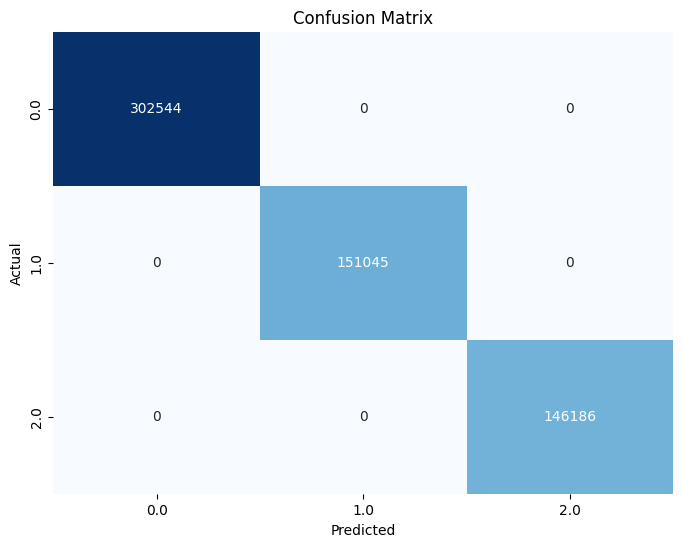

Test accuracy =   1.0


In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Create MulticlassMetrics object
 #Convert predictions and labels to RDD for MulticlassMetrics
prediction_and_labels = predictionsovr.select("prediction", "label") \
    .withColumnRenamed("indexedLabel", "label") \
    .toPandas()  # Convert to Pandas DataFrame for easier manipulation
# Create a confusion matrix using Pandas
confusion_matrix = pd.crosstab(prediction_and_labels['label'], prediction_and_labels['prediction'], rownames=['Actual'], colnames=['Predicted'])

# Plot the confusion matrix using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

evaluator = MulticlassClassificationEvaluator(\
labelCol="label", predictionCol="prediction",\
metricName="accuracy")
accuracy = evaluator.evaluate(predictionsovr)
print("Test accuracy =  " , accuracy)